## KPIs de fiabilité
Cadre conceptuel — à assumer dans le rapport : CMAPSS est un dataset non-réparable (chaque moteur tombe en panne une seule fois, pas de réparations successives). Ce qu'on calcule est donc un MTTF (Mean Time To Failure), pas un MTBF au sens strict. En pratique, dans la plupart des GMAO industrielles, quand l'équipement est remplacé après panne, les deux notions coïncident — c'est la convention que j'adopte.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from lifelines import KaplanMeierFitter
from lifelines.utils import median_survival_times

In [3]:
DATA_DIR = Path("../data/CMAPSSData")
IMG_DIR = Path("../images")
IMG_DIR.mkdir(exist_ok=True)

In [4]:
COLS = ["unit", "cycle"] + [f"op_{i}" for i in range(1, 4)] + [f"s_{i}" for i in range(1, 22)]
train = pd.read_csv(DATA_DIR / "train_FD001.txt", sep=r"\s+", header=None, names=COLS, engine="python")
test = pd.read_csv(DATA_DIR / "test_FD001.txt", sep=r"\s+", header=None, names=COLS, engine="python")
rul_test = pd.read_csv(DATA_DIR / "RUL_FD001.txt", header=None, names=["RUL"]).squeeze("columns")

In [5]:
life_train = train.groupby("unit").cycle.max().values
life_test_true = test.groupby("unit").cycle.max().values + rul_test.values
life_all = np.concatenate([life_train, life_test_true])

In [6]:
def summarise(x, label):
    x = np.asarray(x, dtype=float)
    n = len(x)
    mean = x.mean()
    se = x.std(ddof=1) / np.sqrt(n)
    ci = (mean - 1.96 * se, mean + 1.96 * se)
    return {
        "set": label,
        "N": n,
        "MTTF_mean": mean,
        "MTTF_95CI": f"[{ci[0]:.1f}, {ci[1]:.1f}]",
        "median": np.median(x),
        "B10": np.percentile(x, 10),
        "B50": np.percentile(x, 50),
        "std": x.std(ddof=1),
        "min": x.min(),
        "max": x.max(),
    }

In [7]:
kpi = pd.DataFrame([
    summarise(life_train, "train"),
    summarise(life_test_true, "test"),
    summarise(life_all, "pooled"),
])

In [8]:
print("=" * 72)
print("RELIABILITY KPIs  (units = cycles)")
print("=" * 72)
print(kpi.to_string(index=False))
print("""
Notes:
  - MTTF = Mean Time To Failure (= 'MTBF' in the non-repairable convention
    used in most GMAO tools when equipment is replaced after failure).
  - B10 = 10th-percentile life: cycle at which 10% of units have failed.
  - CI via normal approximation (n=100, reasonable).""")
 
kpi.to_csv("kpi_summary.csv", index=False)

RELIABILITY KPIs  (units = cycles)
   set   N  MTTF_mean      MTTF_95CI  median   B10   B50       std   min   max
 train 100    206.310 [197.2, 215.4]   199.0 154.9 199.0 46.342749 128.0 362.0
  test 100    206.480 [197.8, 215.1]   199.0 153.0 199.0 44.041872 141.0 341.0
pooled 200    206.395 [200.1, 212.6]   199.0 154.0 199.0 45.093303 128.0 362.0

Notes:
  - MTTF = Mean Time To Failure (= 'MTBF' in the non-repairable convention
    used in most GMAO tools when equipment is replaced after failure).
  - B10 = 10th-percentile life: cycle at which 10% of units have failed.
  - CI via normal approximation (n=100, reasonable).


In [9]:
kmf_tr = KaplanMeierFitter(label="train (n=100)")
kmf_tr.fit(life_train, event_observed=np.ones_like(life_train))
kmf_te = KaplanMeierFitter(label="test (n=100)")
kmf_te.fit(life_test_true, event_observed=np.ones_like(life_test_true))
 
median_tr = median_survival_times(kmf_tr.survival_function_)
median_te = median_survival_times(kmf_te.survival_function_)
print(f"\nKaplan-Meier median survival — train: {median_tr:.0f}  |  test: {median_te:.0f} cycles")


Kaplan-Meier median survival — train: 199  |  test: 199 cycles


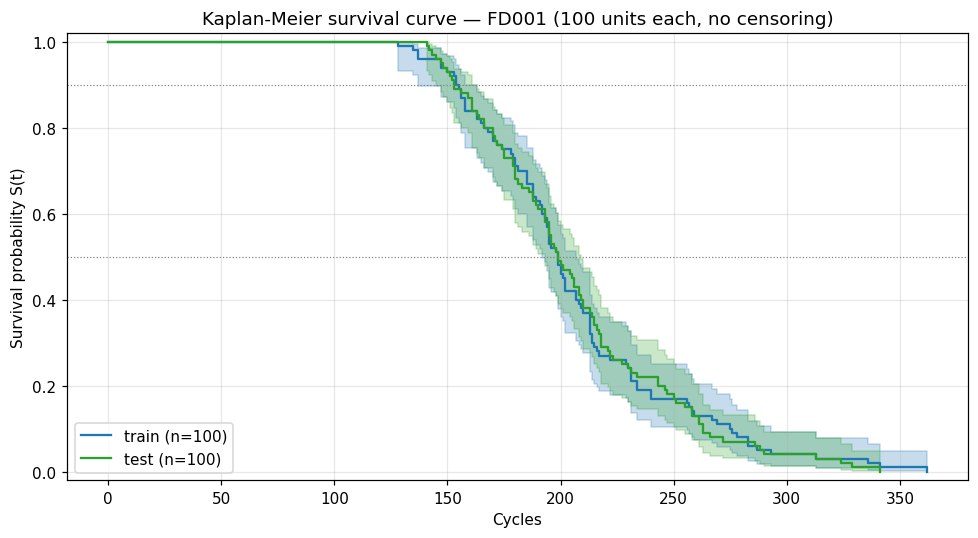

In [11]:
plt.rcParams.update({"figure.dpi": 110, "font.size": 10})
 
fig, ax = plt.subplots(figsize=(9, 5))
kmf_tr.plot_survival_function(ax=ax, ci_show=True, color="tab:blue")
kmf_te.plot_survival_function(ax=ax, ci_show=True, color="tab:green")
ax.axhline(0.5, color="gray", ls=":", lw=0.8)
ax.axhline(0.9, color="gray", ls=":", lw=0.8)
ax.set_xlabel("Cycles")
ax.set_ylabel("Survival probability S(t)")
ax.set_title("Kaplan-Meier survival curve — FD001 (100 units each, no censoring)")
ax.grid(alpha=0.3)
ax.set_ylim(-0.02, 1.02)
plt.tight_layout()
plt.savefig(IMG_DIR / "05_survival.png", bbox_inches="tight")
plt.show()
plt.close()

In [12]:
bin_width = 20
max_t = int(life_all.max()) + bin_width
edges = np.arange(0, max_t + 1, bin_width)
centers = (edges[:-1] + edges[1:]) / 2
n_at_risk = np.array([(life_all >= e).sum() for e in edges[:-1]])
n_events = np.histogram(life_all, bins=edges)[0]
with np.errstate(divide="ignore", invalid="ignore"):
    hazard = np.where(n_at_risk > 0, n_events / (n_at_risk * bin_width), np.nan)

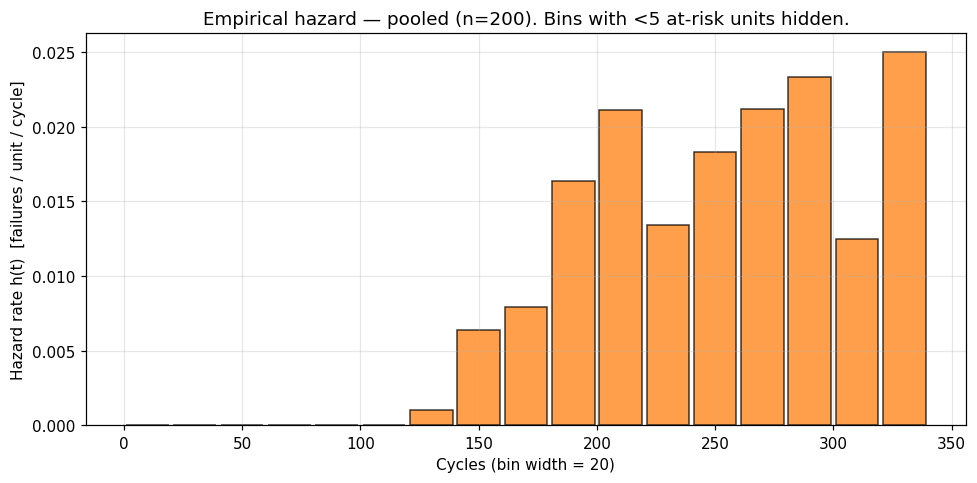

In [13]:
fig, ax = plt.subplots(figsize=(9, 4.5))
mask = n_at_risk >= 5
ax.bar(centers[mask], hazard[mask], width=bin_width * 0.9,
       edgecolor="black", alpha=0.75, color="tab:orange")
ax.set_xlabel("Cycles (bin width = 20)")
ax.set_ylabel("Hazard rate h(t)  [failures / unit / cycle]")
ax.set_title("Empirical hazard — pooled (n=200). Bins with <5 at-risk units hidden.")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(IMG_DIR / "06_hazard.png", bbox_inches="tight")
plt.show()
plt.close()

In [14]:
mttf = life_all.mean()
mttr_range = np.linspace(1, 60, 200)
availability = mttf / (mttf + mttr_range)

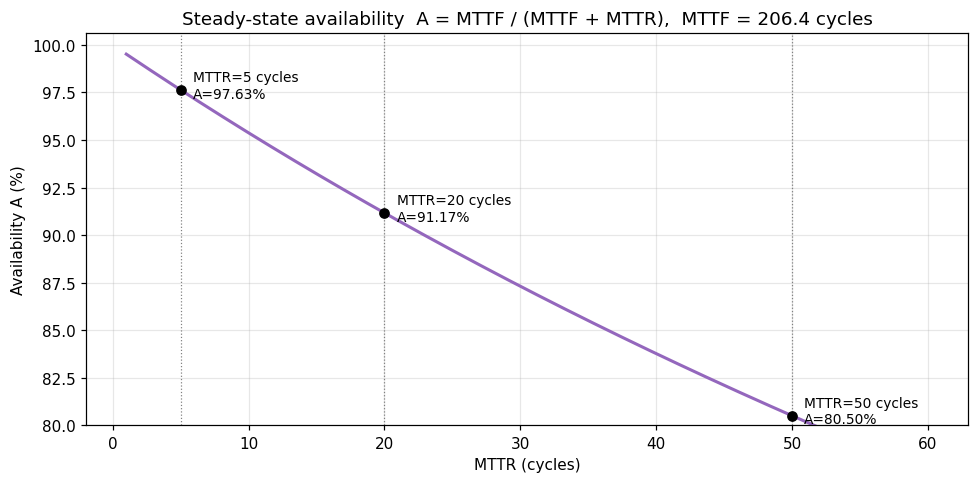

In [16]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(mttr_range, availability * 100, lw=2, color="tab:purple")
for mttr_ref, label in [(5, "5 cycles"), (20, "20 cycles"), (50, "50 cycles")]:
    A = mttf / (mttf + mttr_ref) * 100
    ax.axvline(mttr_ref, color="gray", ls=":", lw=0.8)
    ax.plot(mttr_ref, A, "o", color="black")
    ax.annotate(f"MTTR={label}\nA={A:.2f}%", (mttr_ref, A),
                textcoords="offset points", xytext=(8, -5), fontsize=9)
ax.set_xlabel("MTTR (cycles)")
ax.set_ylabel("Availability A (%)")
ax.set_title(f"Steady-state availability  A = MTTF / (MTTF + MTTR),  MTTF = {mttf:.1f} cycles")
ax.grid(alpha=0.3)
ax.set_ylim(bottom=80)
plt.tight_layout()
plt.savefig(IMG_DIR / "07_availability.png", bbox_inches="tight")
plt.show()
plt.close()